In [3]:
import pandas as pd
import numpy as np

consumption_cleaned= pd.read_csv("../data/processed/consumption_cleaned.csv")
consumption_cleaned


,Unnamed: 0,customer_id,timestamp,consumption_kwh,reading_type,time_difference,date,year,month,day,day_of_week,day_name,hour,minute,settlement_period
0,0,CUST0001,2025-01-01 00:00:00,77.072,ACTUAL,NaN,2025-01-01,2025,1,1,2,Wednesday,0,0,1
1,1,CUST0001,2025-01-01 00:30:00,77.936,ACTUAL,0 days 00:30:00,2025-01-01,2025,1,1,2,Wednesday,0,30,2
2,2,CUST0001,2025-01-01 01:00:00,80.436,ACTUAL,0 days 00:30:00,2025-01-01,2025,1,1,2,Wednesday,1,0,3
3,3,CUST0001,2025-01-01 01:30:00,77.071,ACTUAL,0 days 00:30:00,2025-01-01,2025,1,1,2,Wednesday,1,30,4
4,4,CUST0001,2025-01-01 02:00:00,74.595,ACTUAL,0 days 00:30:00,2025-01-01,2025,1,1,2,Wednesday,2,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494119,494119,CUST0120,2025-03-31 21:30:00,59.326,ACTUAL,0 days 00:30:00,2025-03-31,2025,3,31,0,Monday,21,30,44
494120,494120,CUST0120,2025-03-31 22:00:00,65.732,ACTUAL,0 days 00:30:00,2025-03-31,2025,3,31,0,Monday,22,0,45
494121,494121,CUST0120,2025-03-31 22:30:00,58.121,ACTUAL,0 days 00:30:00,2025-03-31,2025,3,31,0,Monday,22,30,46
494122,494122,CUST0120,2025-03-31 23:00:00,62.640,ACTUAL,0 days 00:30:00,2025-03-31,2025,3,31,0,Monday,23,0,47


In [13]:
consumption_cleaned.columns


Index(['index', 'customer_id', 'timestamp', 'consumption_kwh', 'reading_type',
       'time_difference', 'date', 'year', 'month', 'day', 'day_of_week',
       'day_name', 'hour', 'minute', 'settlement_period'],
      dtype='str')

In [36]:

customer_total =consumption_cleaned.groupby("customer_id")['consumption_kwh'].sum()
customer_total.sort_values(ascending=False)


customer_id
CUST0072    597867.150
CUST0066    561834.391
CUST0082    554222.808
CUST0002    543644.872
CUST0062    513723.025
               ...    
CUST0059     51920.195
CUST0029     50982.275
CUST0091     46574.600
CUST0025     39713.431
CUST0112     24236.297
Name: consumption_kwh, Length: 120, dtype: float64

In [ ]:
print(customer_total.min())
print(customer_total.max())


24236.297
597867.15


pandas.DataFrame

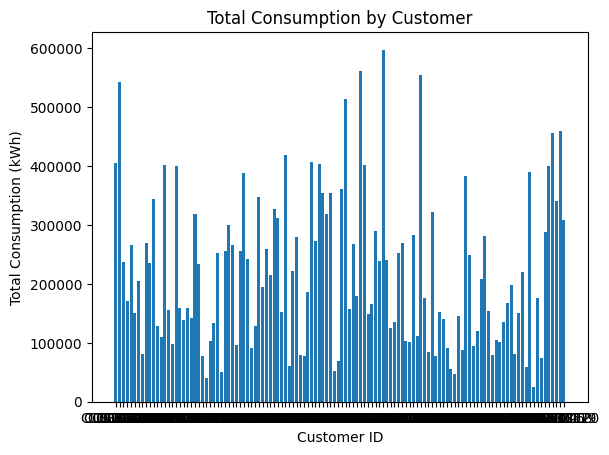

In [67]:
import matplotlib.pyplot as plt

plt.bar(
    customer_total.index,
    customer_total.values
)

plt.xlabel("Customer ID")
plt.ylabel("Total Consumption (kWh)")
plt.title("Total Consumption by Customer")

plt.show()

In [ ]:
consumption_cleaned['consumption_kwh']

KeyError: 'consumption_kwh'

In [38]:
# Plot top 10 customers
customer_total.sort_values(ascending=False).head(10)

customer_id
CUST0072    597867.150
CUST0066    561834.391
CUST0082    554222.808
CUST0002    543644.872
CUST0062    513723.025
CUST0119    459587.338
CUST0117    456212.551
CUST0046    419589.837
CUST0053    407125.032
CUST0001    404705.040
Name: consumption_kwh, dtype: float64

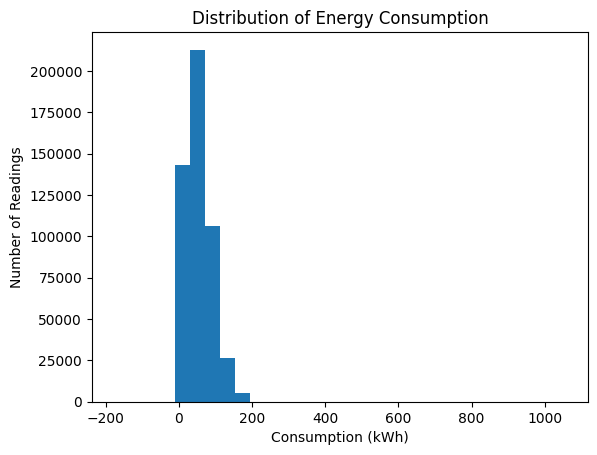

In [58]:
import matplotlib.pyplot as plt 
import matplotlib.pyplot as plt

plt.hist(
    consumption_cleaned["consumption_kwh"],
    bins=30
)

plt.xlabel("Consumption (kWh)")
plt.ylabel("Number of Readings")
plt.title("Distribution of Energy Consumption")

plt.show()

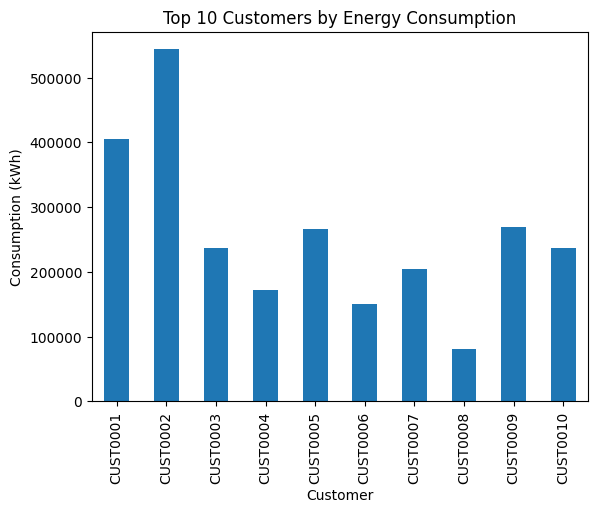

In [ ]:
import matplotlib.pyplot as plt

customer_total.head(10).plot(kind="bar")
plt.title("Top 10 Customers by Energy Consumption")
plt.xlabel("Customer")
plt.ylabel("Consumption (kWh)")
plt.show()

In [74]:
daily_consum=consumption_cleaned.groupby('date')['consumption_kwh'].sum().sort_values(ascending=False)
#consumption_cleaned.columns
daily_consum



date
2025-01-29    324549.416868
2025-01-30    324367.813000
2025-01-31    323825.659208
2025-02-03    322957.211000
2025-02-04    322884.683000
                  ...      
2025-03-15    245677.949000
2025-03-22    239181.724000
2025-03-23    239083.476000
2025-03-29    238289.039000
2025-03-30    238158.814000
Name: consumption_kwh, Length: 90, dtype: float64

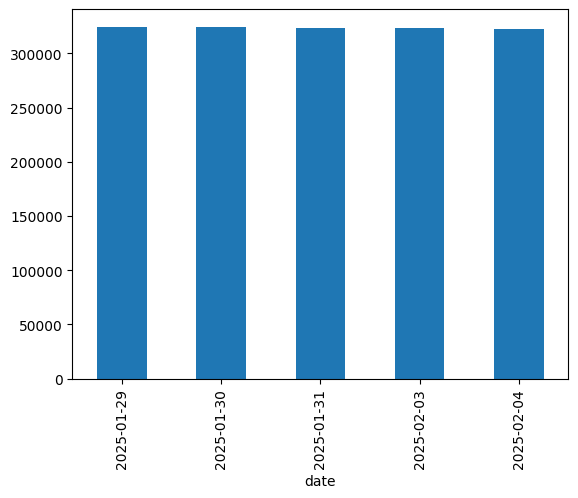

In [81]:
import matplotlib.pyplot as plt 
daily_consum.head(5).plot(kind="bar")
plt.show()


In [82]:
consumption_cleaned.columns

Index(['index', 'customer_id', 'timestamp', 'consumption_kwh', 'reading_type',
       'time_difference', 'date', 'year', 'month', 'day', 'day_of_week',
       'day_name', 'hour', 'minute', 'settlement_period'],
      dtype='str')

In [95]:
consumption_cleaned["timestamp"]=pd.to_datetime(consumption_cleaned["timestamp"])
consumption_cleaned["timestamp"].dtype # thsi is correct dtype('<M8[us]')


consumption_cleaned["year_month"]=(consumption_cleaned["timestamp"].dt.to_period("M"))


In [98]:
consumption_cleaned

,index,customer_id,timestamp,consumption_kwh,reading_type,time_difference,date,year,month,day,day_of_week,day_name,hour,minute,settlement_period,year_month
0,0,CUST0001,2025-01-01 00:00:00,77.072,ACTUAL,NaN,2025-01-01,2025,1,1,2,Wednesday,0,0,1,2025-01
1,1,CUST0001,2025-01-01 00:30:00,77.936,ACTUAL,0 days 00:30:00,2025-01-01,2025,1,1,2,Wednesday,0,30,2,2025-01
2,2,CUST0001,2025-01-01 01:00:00,80.436,ACTUAL,0 days 00:30:00,2025-01-01,2025,1,1,2,Wednesday,1,0,3,2025-01
3,3,CUST0001,2025-01-01 01:30:00,77.071,ACTUAL,0 days 00:30:00,2025-01-01,2025,1,1,2,Wednesday,1,30,4,2025-01
4,4,CUST0001,2025-01-01 02:00:00,74.595,ACTUAL,0 days 00:30:00,2025-01-01,2025,1,1,2,Wednesday,2,0,5,2025-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494119,494119,CUST0120,2025-03-31 21:30:00,59.326,ACTUAL,0 days 00:30:00,2025-03-31,2025,3,31,0,Monday,21,30,44,2025-03
494120,494120,CUST0120,2025-03-31 22:00:00,65.732,ACTUAL,0 days 00:30:00,2025-03-31,2025,3,31,0,Monday,22,0,45,2025-03
494121,494121,CUST0120,2025-03-31 22:30:00,58.121,ACTUAL,0 days 00:30:00,2025-03-31,2025,3,31,0,Monday,22,30,46,2025-03
494122,494122,CUST0120,2025-03-31 23:00:00,62.640,ACTUAL,0 days 00:30:00,2025-03-31,2025,3,31,0,Monday,23,0,47,2025-03


In [ ]:
monthly_consumption = (consumption_cleaned.groupby("year_month")["consumption_kwh"].sum()
)

monthly_consumption

year_month
2025-01    9.249902e+06
2025-02    8.370875e+06
2025-03    8.938744e+06
Freq: M, Name: consumption_kwh, dtype: float64

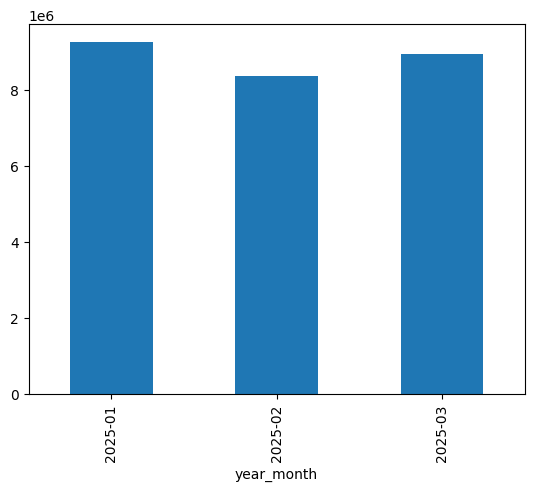

In [109]:
monthly_consumption.plot(kind="bar")
plt.show()